In [2]:
import gdown
import zipfile
import os
import shutil

In [3]:
# Google Drive link
file_url = "https://drive.google.com/file/d/1oUX991nPh4330ZzbXzBKKOAswhx75BtV/view?usp=sharing"

# Output filename
output = "dataset.zip"


In [7]:
# Download directly from Google Drive
gdown.download(file_url, output, quiet = False, fuzzy = True)

# Extract the zip file
extract_dir = "/content/images"
with zipfile.ZipFile(output, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

FileURLRetrievalError: Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV

but Gdown can't. Please check connections and permissions.

Loading images

In [17]:
import random
import zipfile
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing import image

In [25]:
image_dir = "/content/images/images"

In [26]:
print("Total files extracted:", sum(len(files) for _, _, files in os.walk(image_dir)))
print("Sample files:", os.listdir(image_dir)[:10])

Total files extracted: 34731
Sample files: ['435fc81ba00cfb2dcce585b6e98702fbffee2997.jpg', '88418faead1205fb141a3d63a5b268b804784568.jpg', '6074cffd7f8dc9f96ac141d5633bfbd49677b732.jpg', '0e918c211e5b966421156f7847825186f2ea7daa.jpg', '6d7f357c0f0eafc6f37774666db6e80f5a3fa3a0.jpg', 'adb02e92e93f9578dd1fe7cd982018fc9b564c36.jpg', '2de017d26329d3fea91b29e22a73962bbdc82b60.jpg', 'b958dc8a452916a66058f3ae3507aacd51a8205f.jpg', '29ddbd18d005b9aa7b2f44a847cb31f0b2c8a2b2.jpg', '6fa5b8a7e9f11885314a7df0c9c650585ce22787.jpg']


In [27]:
image_files = [f for f in os.listdir(image_dir) if f.endswith(".jpg") or f.endswith(".png")]

In [28]:
# List files in the image directory
print(os.listdir(image_dir))

['435fc81ba00cfb2dcce585b6e98702fbffee2997.jpg', '88418faead1205fb141a3d63a5b268b804784568.jpg', '6074cffd7f8dc9f96ac141d5633bfbd49677b732.jpg', '0e918c211e5b966421156f7847825186f2ea7daa.jpg', '6d7f357c0f0eafc6f37774666db6e80f5a3fa3a0.jpg', 'adb02e92e93f9578dd1fe7cd982018fc9b564c36.jpg', '2de017d26329d3fea91b29e22a73962bbdc82b60.jpg', 'b958dc8a452916a66058f3ae3507aacd51a8205f.jpg', '29ddbd18d005b9aa7b2f44a847cb31f0b2c8a2b2.jpg', '6fa5b8a7e9f11885314a7df0c9c650585ce22787.jpg', 'eeb4d059a0a01a54eb3a07af788b7ffd8f5c2af6.jpg', 'fb54e70e24d4c51b923ced01ab19be29361f82af.jpg', '80f210930bda6132da26627277872f6456048ddd.jpg', '4110d741a12e2fcd1d78f6340e74f37c9f658563.jpg', '16a96169e7e05f4c9c160f9e2382a7b935d90340.jpg', 'e7546b514a3c3d7bbd75d8fe2a1d824cc41076b3.jpg', 'd6f8e4d09e652c5294fb2fca546685a3b35e48e6.jpg', '0ac8c4d0222f34433ca8887dbdf0dbf498c782fb.jpg', '588f1a106cc82d1ba2d1174969b1f5eb140c68e5.jpg', '23dc0af4567592c0005566189f511d762b57370f.jpg', '937ba8253e2409544934897da1e8d0e8831289

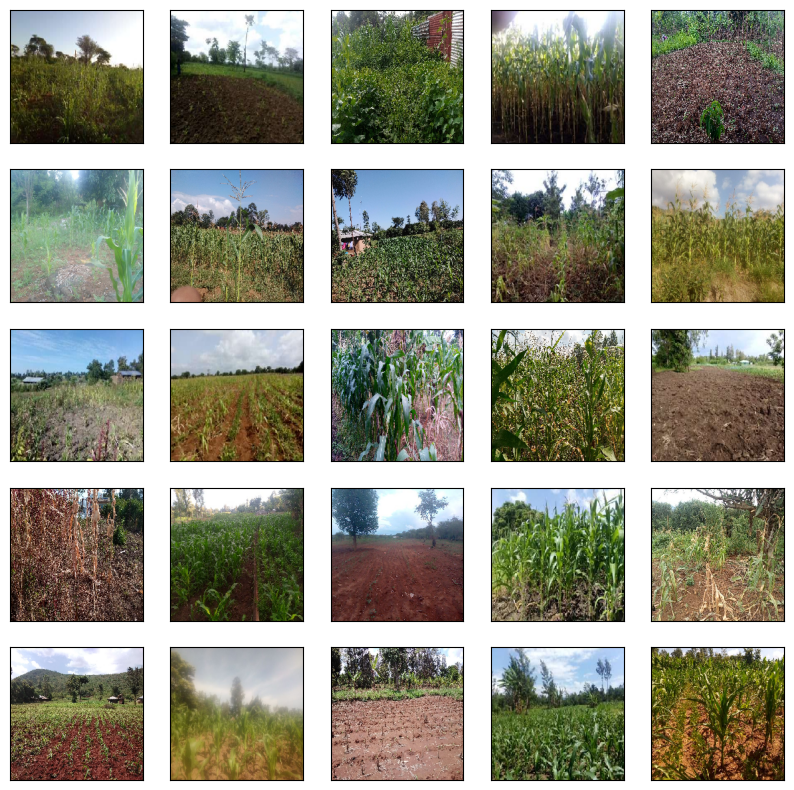

In [29]:
plt.figure(figsize = (10, 10))
# Select a subset of image files to display
sample_files = random.sample(image_files, min(25, len(image_files)))
for i, file in enumerate(sample_files):
  img_path = os.path.join(image_dir, file)
  img = image.load_img(img_path, target_size = (200, 200))  # Adjust the target size as needed
  plt.subplot(5, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(img)
plt.show()

In [30]:
from PIL import Image
from tqdm import tqdm
import hashlib
import pandas as pd

In [31]:
input_dir = "/content/images/images"

Checking for corrupted images

In [33]:
bad_files = []

# Collect all image file paths
image_files = []
for dirpath, _, filenames in os.walk(image_dir):
    for f in filenames:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(dirpath, f))  # full path!

# Check each image
for path in tqdm(image_files, desc="Checking for corrupted images"):
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception:
        bad_files.append(path)
        try:
            os.remove(path)  # delete corrupted file
        except FileNotFoundError:
            pass  # file already gone

print(f"✅ Removed {len(bad_files)} corrupted images")

Checking for corrupted images: 100%|██████████| 34731/34731 [00:03<00:00, 9157.37it/s]

✅ Removed 0 corrupted images


Checking for duplicates

In [34]:
seen = set()
duplicates = []

for path in tqdm(image_files, desc = "Checking for duplicates"):
    try:
        with open(path, "rb") as f:
            hash_val = hashlib.md5(f.read()).hexdigest()
        if hash_val in seen:
            os.remove(path)
            duplicates.append(path)
        else:
            seen.add(hash_val)
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(path)}: {e}")

print(f"✅ Removed {len(duplicates)} duplicate images")

Checking for duplicates: 100%|██████████| 34731/34731 [01:51<00:00, 310.50it/s]

✅ Removed 0 duplicate images


Removing Outliers

In [35]:
min_size = 50  # min width/height
max_size = 5000  # max width/height

for root, _, files in os.walk(input_dir):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            if img.width < min_size or img.height < min_size or img.width > max_size or img.height > max_size:
                os.remove(path)
        except:
            pass

In [ ]:
# pick first 10 image paths
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [ ]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


In [36]:
# Target Size
size = (300, 300)

In [ ]:
for img_path in tqdm(image_files, desc = "Resizing images"):
    try:
        with Image.open(img_path).convert("RGB") as img:
            img = img.resize(size, Image.Resampling.LANCZOS)
            img.save(img_path, "JPEG")
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(img_path)}: {e}")

Resizing images:  39%|███▉      | 13481/34731 [10:09<23:39, 14.97it/s]

In [ ]:
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [ ]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


Preparation Toward Model training

In [ ]:
train = pd.read_csv("Train.csv")

In [ ]:
train.head()

,ID,damage,filename
0,ID_UBHORS,WD,d036341be8d6cd59851cb80bcc9a70cc9fbdba30.jpg
1,ID_9DSOLZ,G,9ea16180c50d0cd539897eefbfe585314e50a56b.jpg
2,ID_JHLM0G,G,b6b564844041bc68774a553eaf43d61654657dd9.jpg
3,ID_ATREIJ,DR,62262859f0cd411aaf484082ed3ef0b625bc452a.jpg
4,ID_L2GAD6,G,03b6e2a8ace7cb611eccba289f3c83d9bd497584.jpg


In [ ]:
import shutil
from pathlib import Path

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test = train_test_split(train, test_size = 0.2, random_state = 42)

In [ ]:
len(X_train)

20854

In [ ]:
len(X_test)

5214

Mapping Damage type to images

In [ ]:
filename_col = "filename"
damage_col = "damage"

In [122]:
# Go through each row and rename files
renamed_count = 0
for _, row in df.iterrows():
    old_name = str(row[filename_col]).lower()
    damage = str(row[damage_col]).replace(" ", "_").lower()  # safe folder name

    old_path = os.path.join(image_dir, old_name)

    if os.path.exists(old_path):
        # New filename: damageType_index.ext
        ext = os.path.splitext(old_name)[1]  # keep .jpg/.png
        new_name = f"{damage}_{renamed_count}{ext}"
        new_path = os.path.join(image_dir, new_name)

        os.rename(old_path, new_path)
        renamed_count += 1

print(f"✅ Done! Renamed {renamed_count} images in {image_dir}")

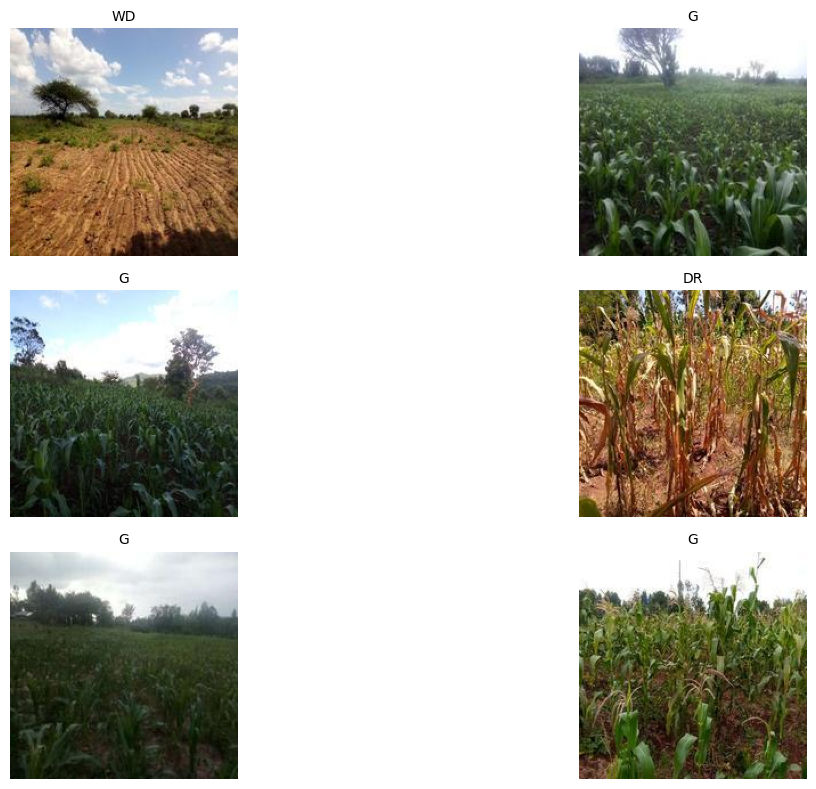

In [123]:
preview_images(0, n = 6)

Moving Mapped images into a new folder

In [128]:
output_dir = "dataset_split/mapped"
filename_col = "filename"

In [129]:
csv_files = set(train[filename_col].str.lower().tolist())

In [125]:
all_images = {}
for dirpath, _, filenames in os.walk(image_dir):
    for f in filenames:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            all_images[f.lower()] = os.path.join(dirpath, f)

In [127]:
os.makedirs(output_dir, exist_ok = True)

In [130]:
moved_count = 0
for fname in csv_files:
    if fname in all_images:
        src = all_images[fname]
        dst = os.path.join(output_dir, fname)
        shutil.move(src, dst)
        moved_count += 1

Confiming the total number of images mapped and moved to the new folder

In [132]:
len(train)

26068

In [131]:
mapped_dir = "/content/dataset_split/mapped"

print("Total mapped files:", sum(len(files) for _, _, files in os.walk(mapped_dir)))

Total mapped files: 26068


In [164]:
# Get a list of all image files
all_images = []
for root, dirs, files in os.walk(mapped_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_images.append(os.path.join(root, file))

In [165]:
# Randomly select 5 images
sample_images = random.sample(all_images, 5)

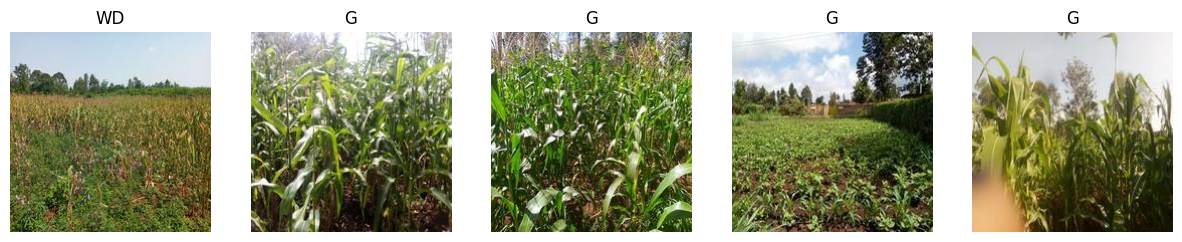

In [166]:
# Display images
plt.figure(figsize=(15,5))
for i, img_path in enumerate(sample_images, 1):
    img = mpimg.imread(img_path)
    plt.subplot(1, 5, i)
    plt.imshow(img)
    plt.title(os.path.basename(os.path.dirname(img_path)))  # class name
    plt.axis('off')
plt.show()

In [133]:
dataset_dir = "/content/dataset_split/mapped"
base_dir = "/content/dataset"

In [140]:
# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

In [141]:
import shutil
import random

In [142]:
# Create train, val, and test directories within the base directory, organized by class (damage type)
for split in ["train", "val", "test"]:
    for class_name in train[damage_col].unique():
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

# Combine train and test dataframes for splitting
df_combined = pd.concat([X_train, X_test])

# Split the combined dataframe into train, validation, and test sets
X_train_split, X_temp = train_test_split(df_combined, test_size = val_ratio + test_ratio, random_state = 42)
X_val_split, X_test_split = train_test_split(X_temp, test_size = test_ratio / (val_ratio + test_ratio), random_state = 42)

# Move images to the respective directories
for index, row in tqdm(X_train_split.iterrows(), total = len(X_train_split), desc = "Moving training images"):
    fname = str(row[filename_col]).lower()
    damage = row[damage_col]
    source_path = os.path.join(mapped_dir, fname)
    dest_path = os.path.join(base_dir, "train", damage, fname)
    if os.path.exists(source_path):
        shutil.copy(source_path, dest_path)
    else:
        print(f"⚠️ Warning: Image file not found in mapped data: {fname}")


for index, row in tqdm(X_val_split.iterrows(), total = len(X_val_split), desc = "Moving validation images"):
    fname = str(row[filename_col]).lower()
    damage = row[damage_col]
    source_path = os.path.join(mapped_dir, fname)
    dest_path = os.path.join(base_dir, "val", damage, fname)
    if os.path.exists(source_path):
        shutil.copy(source_path, dest_path)
    else:
        print(f"⚠️ Warning: Image file not found in mapped data: {fname}")

for index, row in tqdm(X_test_split.iterrows(), total = len(X_test_split), desc = "Moving testing images"):
    fname = str(row[filename_col]).lower()
    damage = row[damage_col]
    source_path = os.path.join(mapped_dir, fname)
    dest_path = os.path.join(base_dir, "test", damage, fname)
    if os.path.exists(source_path):
        shutil.copy(source_path, dest_path)
    else:
        print(f"⚠️ Warning: Image file not found in mapped data: {fname}")

print("\n✅ Images successfully split and moved into train, val, and test folders.")

Moving testing images: 100%|██████████| 3911/3911 [00:02<00:00, 1581.27it/s]


✅ Images successfully split and moved into train, val, and test folders.


In [143]:
mapped_dir = "/content/dataset/train"

print("Total mapped files:", sum(len(files) for _, _, files in os.walk(mapped_dir)))

Total mapped files: 18247


Normalize Pixel Values

In [144]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255)
val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

Data Augmentation on the train

In [146]:
train_datagen = ImageDataGenerator(
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = "nearest"
)


In [148]:
import tensorflow as tf
from tensorflow.keras import layers, models

Building CNN model using 5 classes

In [158]:
num_classes = 5

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation = "relu", input_shape  = (200, 200, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation = "relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation = "relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation = "softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compiling Model Using Adam

In [159]:
model.compile(optimizer = "adam",
              loss = "categorical_crossentropy",
              metrics =["accuracy"])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,157 (33.42 MB)

 Trainable params: 8,761,157 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

Model Fitting

In [160]:
train_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size = (200, 200),
    batch_size = 32,
    class_mode = "categorical"
)

val_generator = val_datagen.flow_from_directory(
    "dataset/val",
    target_size = (200, 200),
    batch_size = 32,
    class_mode = "categorical"
)

Found 18247 images belonging to 26073 classes.
Found 3910 images belonging to 26073 classes.


In [161]:
history = model.fit(train_generator,
                    epochs = 20,
                    validation_data = val_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 26073), output.shape=(None, 5)